# Delta 训练天数探索

目标：在效果尽量不明显退化的前提下，寻找尽量少的训练日，并比较 `recent / random / volatility_stratified` 三种采样方式。

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('/home/jovyan/work/tactics_demo')

import matplotlib.pyplot as plt
import pandas as pd

from delta import (
    create_feature,
    create_y,
    get_trade_dates,
    split_dates_by_range,
    summarize_daily_volatility,
    assign_volatility_bins,
    sample_dates_by_volatility,
    run_training_subset_experiment,
    load_daily_sample_cache,
    concat_sample_cache,
    train_model,
    evaluate_model,
)

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 200)

In [3]:
instrument_id = '518880'

param_dict = {
    'instrument_id': instrument_id,
    'trade_ymd': '20260319',
    'name': 'delta_v1_volatility_stratified',
    'stride': 1,
    'short_window': 300,
    'long_window': 600,
    'y_window': 600,
    'open_threshold': 3,
    'open_confidence': 0,
    'standard_num': 1000,
    'atr_multiplier': 4,
    'vol_window': 600,
    'k_up': 3,
    'k_down': 3,
    'stop_tighten_start': 3000,
    'stop_tighten_step': 6000,
    'stop_tighten_factor': 1,
    'stop_tighten_floor': 0.75,
    'model_type': 'xgboost',
    'model_params': {
        'n_estimators': 800,
        'max_depth': 3,
        'learning_rate': 0.03,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'random_state': 42,
        'n_jobs': 1,
        'verbosity': 1,
        'beta': 0.5,
    },
}
param_dict['x_window'] = max(param_dict['short_window'], param_dict['long_window'])

In [4]:
trade_dates = get_trade_dates()

train_candidate_dates, _, _ = split_dates_by_range(
    trade_dates,
    train_start='20250901',
    train_end='20260227',
)

_, valid_dates, _ = split_dates_by_range(
    trade_dates,
    valid_start='20260303',
    valid_end='20260311',
)

_, _, test_dates = split_dates_by_range(
    trade_dates,
    test_start='20260313',
    test_end='20260409',
)

print('训练候选天数:', len(train_candidate_dates))
print('验证集天数:', len(valid_dates))
print('测试集天数:', len(test_dates))

训练集: 20250901 ~ 20260227 (59天)
验证集: 无
测试集: 无
训练集: 无
验证集: 20260303 ~ 20260311 (4天)
测试集: 无
训练集: 无
验证集: 无
测试集: 20260313 ~ 20260409 (11天)
训练候选天数: 59
验证集天数: 4
测试集天数: 11


In [5]:
stats_df = summarize_daily_volatility(instrument_id, train_candidate_dates)
stats_df = assign_volatility_bins(stats_df, vol_col='realized_volatility', n_bins=5)
stats_df

,trade_ymd,n_snapshots,open_price,close_price,close_to_close_return,realized_volatility,intraday_std,normalized_range,vol_bucket
0,20250901,14402,7.546,7.647,0.013385,0.011232,0.003853,0.015372,4
1,20250903,14402,7.762,7.769,0.000902,0.009945,0.001143,0.005153,4
2,20250905,14402,7.773,7.776,0.000386,0.009138,0.000682,0.003474,2
3,20250909,14402,7.934,7.966,0.004033,0.009650,0.001603,0.007058,3
4,20250911,14402,7.963,7.923,-0.005023,0.009172,0.001905,0.008414,3
5,20250915,14402,7.910,7.931,0.002655,0.008519,0.000948,0.005057,1
6,20250917,14402,8.010,7.963,-0.005868,0.009127,0.001030,0.006742,2
7,20250919,14402,7.901,7.900,-0.000127,0.009170,0.001053,0.006075,3
8,20250923,14402,8.125,8.144,0.002338,0.009159,0.001455,0.005415,2
9,20250925,14402,8.160,8.146,-0.001716,0.008790,0.000910,0.005392,2


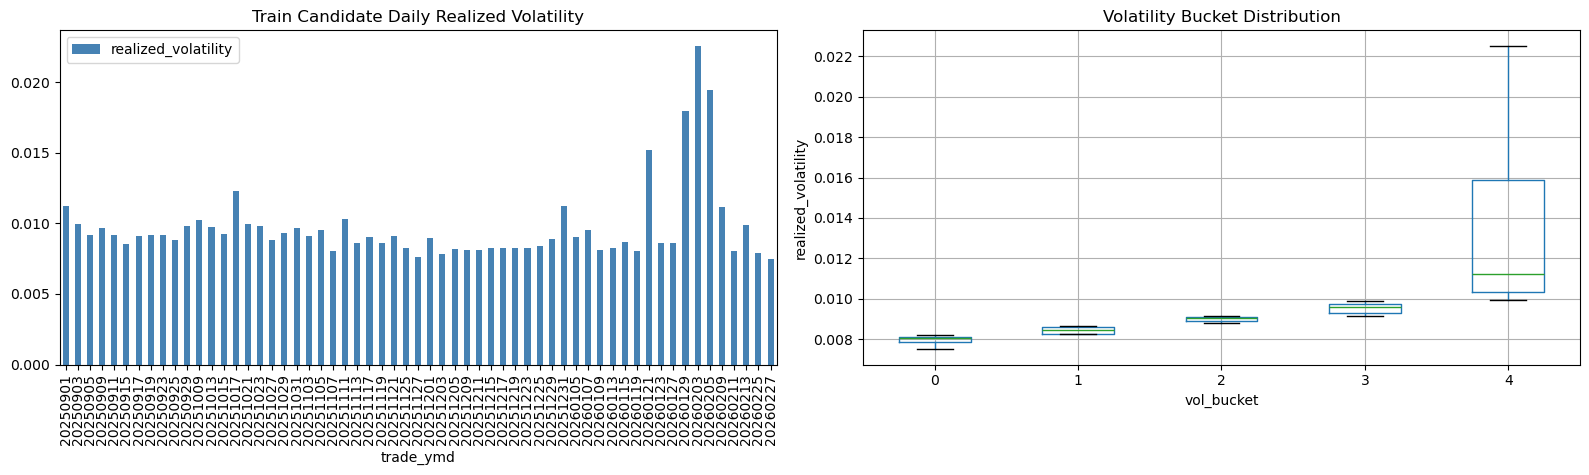

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

stats_df.plot(
    x='trade_ymd',
    y='realized_volatility',
    kind='bar',
    ax=axes[0],
    color='steelblue',
    title='Train Candidate Daily Realized Volatility',
)
axes[0].tick_params(axis='x', rotation=90)

stats_df.boxplot(column='realized_volatility', by='vol_bucket', ax=axes[1])
axes[1].set_title('Volatility Bucket Distribution')
axes[1].set_xlabel('vol_bucket')
axes[1].set_ylabel('realized_volatility')
plt.suptitle('')
plt.tight_layout()
plt.show()

In [7]:
train_day_grid = [4, 6, 8, 10, 12, 16, 20, 24, 32]

result_df, summary_df, stats_df = run_training_subset_experiment(
    instrument_id=instrument_id,
    train_candidate_dates=train_candidate_dates,
    valid_dates=valid_dates,
    test_dates=test_dates,
    param_dict=param_dict,
    feature_func=create_feature,
    y_func=create_y,
    train_day_grid=train_day_grid,
    strategies=('recent', 'random', 'volatility_stratified'),
    repeats=3,
    random_seed=42,
    n_bins=5,
)

summary_df

加载按天样本缓存...
20250901: 产生 328 个样本
20250903: 产生 326 个样本
20250905: 产生 298 个样本
20250909: 产生 315 个样本
20250911: 产生 292 个样本
20250915: 产生 321 个样本
20250917: 产生 307 个样本
20250919: 产生 329 个样本
20250923: 产生 333 个样本
20250925: 产生 291 个样本
20250929: 产生 330 个样本
20251009: 产生 333 个样本
20251013: 产生 316 个样本
20251015: 产生 335 个样本
20251017: 产生 332 个样本
20251021: 产生 335 个样本
20251023: 产生 334 个样本
20251027: 产生 328 个样本
20251029: 产生 321 个样本
20251031: 产生 341 个样本
20251103: 产生 341 个样本
20251105: 产生 344 个样本
20251107: 产生 300 个样本
20251111: 产生 312 个样本
20251113: 产生 324 个样本
20251117: 产生 338 个样本
20251119: 产生 294 个样本
20251121: 产生 377 个样本
20251125: 产生 311 个样本
20251127: 产生 328 个样本
20251201: 产生 320 个样本
20251203: 产生 314 个样本
20251205: 产生 310 个样本
20251209: 产生 341 个样本
20251211: 产生 337 个样本
20251215: 产生 316 个样本
20251217: 产生 290 个样本
20251219: 产生 297 个样本
20251223: 产生 306 个样本
20251225: 产生 255 个样本
20251229: 产生 329 个样本
20251231: 产生 315 个样本
20260105: 产生 261 个样本
20260107: 产生 312 个样本
20260109: 产生 293 个样本
20260113: 产生 327 个样本
20260115: 产生 329 个样本
2

,strategy,train_days,accuracy_mean,accuracy_std,f1_mean,f1_std,ap_mean,ap_std,pr_auc_mean,pr_auc_std,train_samples_mean
0,random,4,0.634925,0.033710,0.389390,0.142259,0.431510,0.013177,0.430744,0.013377,1264.000000
1,recent,4,0.537910,0.000000,0.513819,0.000000,0.437606,0.000000,0.436665,0.000000,1235.000000
2,volatility_stratified,4,0.649652,0.010698,0.403110,0.024242,0.430913,0.017781,0.429935,0.017805,1294.000000
3,random,6,0.631642,0.039952,0.365357,0.234411,0.432678,0.017066,0.431855,0.017141,1912.000000
4,recent,6,0.431343,0.000000,0.492946,0.000000,0.420132,0.000000,0.419425,0.000000,1849.000000
5,volatility_stratified,6,0.625473,0.038333,0.435905,0.115661,0.435904,0.014354,0.435047,0.014402,1923.000000
6,random,8,0.627463,0.029891,0.411074,0.179906,0.444765,0.026450,0.444108,0.026394,2543.333333
7,recent,8,0.563582,0.000000,0.484121,0.000000,0.421009,0.000000,0.420232,0.000000,2436.000000
8,volatility_stratified,8,0.673333,0.009318,0.302454,0.107929,0.434209,0.010419,0.433384,0.010590,2539.000000
9,random,10,0.634328,0.027761,0.425335,0.157697,0.445983,0.020871,0.445109,0.020826,3173.666667


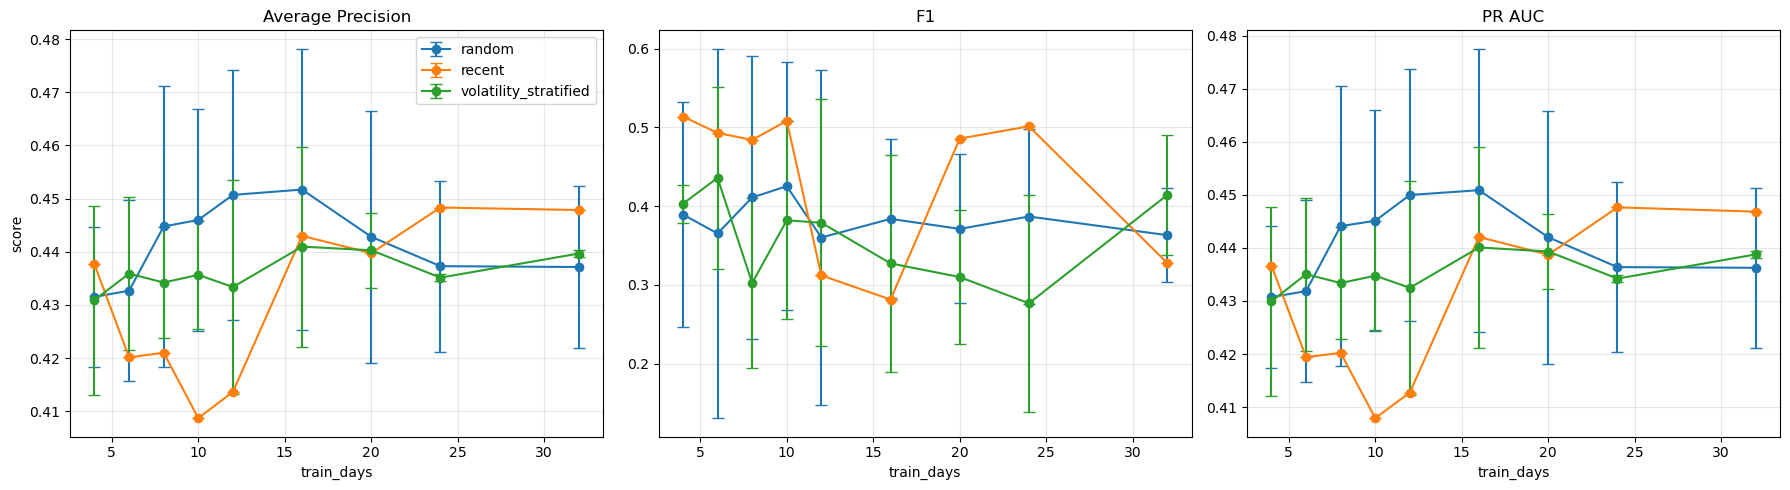

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)
metric_pairs = [
    ('ap_mean', 'ap_std', 'Average Precision'),
    ('f1_mean', 'f1_std', 'F1'),
    ('pr_auc_mean', 'pr_auc_std', 'PR AUC'),
]

for ax, (mean_col, std_col, title) in zip(axes, metric_pairs):
    for strategy_name, part in summary_df.groupby('strategy'):
        ax.errorbar(
            part['train_days'],
            part[mean_col],
            yerr=part[std_col],
            marker='o',
            capsize=4,
            label=strategy_name,
        )
    ax.set_title(title)
    ax.set_xlabel('train_days')
    ax.grid(alpha=0.3)

axes[0].set_ylabel('score')
axes[0].legend()
plt.tight_layout()
plt.show()

In [9]:
target_metric = 'ap_mean'
retain_ratio = 0.98

best_score = summary_df[target_metric].max()
candidate_summary = summary_df[summary_df[target_metric] >= best_score * retain_ratio].copy()
recommended_row = candidate_summary.sort_values(['train_days', target_metric], ascending=[True, False]).iloc[0]
recommended_row

strategy                   random
train_days                      8
accuracy_mean            0.627463
accuracy_std             0.029891
f1_mean                  0.411074
f1_std                   0.179906
ap_mean                  0.444765
ap_std                    0.02645
pr_auc_mean              0.444108
pr_auc_std               0.026394
train_samples_mean    2543.333333
Name: 6, dtype: object

In [10]:
recommended_days = int(recommended_row['train_days'])
recommended_dates = sample_dates_by_volatility(
    stats_df,
    sample_size=recommended_days,
    random_seed=42,
    n_bins=5,
)
recommended_dates

['20250915',
 '20250925',
 '20250929',
 '20251015',
 '20251127',
 '20260127',
 '20260129',
 '20260225']

20250915: 产生 321 个样本
20250925: 产生 291 个样本
20250929: 产生 330 个样本
20251015: 产生 335 个样本
20251127: 产生 328 个样本
20260127: 产生 296 个样本
20260129: 产生 289 个样本
20260225: 产生 313 个样本
20260303: 产生 314 个样本
20260305: 产生 278 个样本
20260309: 产生 344 个样本
20260311: 产生 310 个样本
20260313: 产生 282 个样本
20260317: 产生 320 个样本
20260319: 产生 309 个样本
20260323: 产生 297 个样本
20260325: 产生 297 个样本
20260327: 产生 306 个样本
20260331: 产生 278 个样本
20260401: 产生 304 个样本
20260403: 产生 325 个样本
20260407: 产生 301 个样本
20260409: 产生 331 个样本
训练 xgboost 模型...
[0]	validation_0-logloss:0.69176
[100]	validation_0-logloss:0.67166
[200]	validation_0-logloss:0.70185
[300]	validation_0-logloss:0.71496
[400]	validation_0-logloss:0.72816
[500]	validation_0-logloss:0.73445
[600]	validation_0-logloss:0.73519
[700]	validation_0-logloss:0.74262
[799]	validation_0-logloss:0.75253
阈值优化完成: Best Threshold=0.5127, F0.5=0.4624

特征重要性（前10个）:
volatility    0.149199
WAMP          0.099969
alpha_04      0.084447
spread        0.081490
alpha_02      0.077341
alpha_05      0

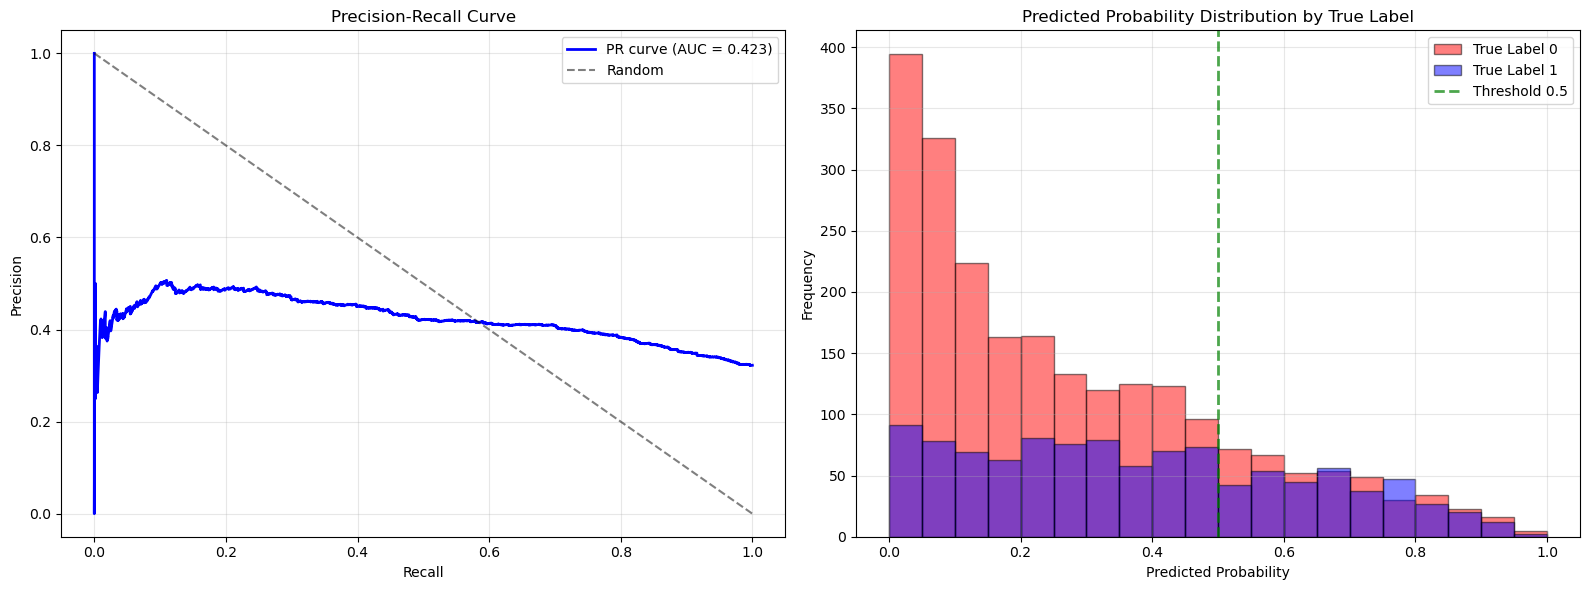

0.6626865671641791

In [11]:
cache_dates = sorted(set(recommended_dates) | set(valid_dates) | set(test_dates))
sample_cache = load_daily_sample_cache(
    cache_dates,
    instrument_id,
    param_dict,
    create_feature,
    create_y,
)

X_train, y_train, feature_names = concat_sample_cache(sample_cache, recommended_dates)
X_valid, y_valid, _ = concat_sample_cache(sample_cache, valid_dates)
X_test, y_test, _ = concat_sample_cache(sample_cache, test_dates)

model = train_model(X_train, y_train, X_valid, y_valid, param_dict, feature_names)
evaluate_model(model, X_test, y_test, show_plots=True)

结论建议：

1. 先看 `summary_df` 中 `volatility_stratified` 在小样本训练日下是否显著优于 `recent/random`。
2. 再结合 `retain_ratio` 调整“接近最优”的容忍度，例如 `0.97 ~ 0.99`。
3. 如果最终策略仍要上线，建议把推荐训练日固定为一个可复现的日期列表，而不是每次重新随机抽样。